In [1]:
import torch
from torch import nn, Tensor
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
import torch.nn.functional as F
from torch.autograd import grad
from torchdiffeq import odeint
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import math

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cuda


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from torch.optim.lr_scheduler import ReduceLROnPlateau
from scipy.stats import entropy

# for cleaner look (set your theme to dark mode)
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#1E1E1E'
plt.rcParams['axes.facecolor'] = '#1E1E1E'
plt.rcParams['savefig.facecolor'] = '#1E1E1E'

from tqdm import tqdm
import os
import matplotlib.animation as animation
from IPython.display import Image, display
from PIL import Image as PILImage
import io
from IPython.display import Image


In [4]:
# this box fuses the loose data files such that they can be read by the dataset object
base_in = '../../data/CFD/grid/loose/'
base_out2 = '../../data/CFD/grid/concat/'
os.makedirs(base_out2, exist_ok=True)
for Re in [100,150,200,250,300,350,400]:
    u = np.load(f"{base_in}u_grid_Re{Re}.npy")
    v = np.load(f"{base_in}v_grid_Re{Re}.npy")
    p = np.load(f"{base_in}p_grid_Re{Re}.npy")
    concat = np.stack([u, v, p], axis=1)
    filename_save = f"{base_out2}uvp_grid_Re{Re}.npy"
    np.save(filename_save, concat)

In [5]:
class FlowDataset(Dataset):
    def __init__(self, filenames, flip_augmentation=False, timesample=1):
        self.sequences = []
        self.index_map = []
        self.flip_augmentation = flip_augmentation

        # coordinates
        self.coordsy = np.linspace(-5, 5, 64, endpoint=True)
        self.coordsx = np.linspace(-10, 10, 128, endpoint=True)
        self.coords = np.array(np.meshgrid(self.coordsx, self.coordsy)).T.reshape(128, 64, 2)
        self.coords = torch.tensor(self.coords, dtype=torch.float32).permute(2, 1, 0).cuda()

        # use coordinates to make obstacle mask
        center = torch.tensor([-5.0, 0.0], device=self.coords.device).view(2, 1, 1)
        radius = 0.5
        squared_distance = ((self.coords - center) ** 2).sum(dim=0) 
        self.mask = squared_distance < radius**2  # shape [64, 128]
        self.mask = self.mask.unsqueeze(0).cuda()

        # sample/read the data
        for seq_idx, filename in enumerate(filenames):
            data = np.load(filename)  
            data = data[::timesample] 
            self.sequences.append(data)
            T = data.shape[0]
            self.index_map.extend([(seq_idx, t) for t in range(T - 1)])

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        seq_idx, t = self.index_map[idx]
        seq = self.sequences[seq_idx]
        input = seq[t]    
        target = seq[t + 1] 

        # if flip augmentation is true then flip the data horizontally 50% of the time
        if self.flip_augmentation and np.random.rand() > 0.5:
            input = self.flip(input)
            target = self.flip(target)
        return (
                self.mask, 
                self.coords, 
                torch.tensor(input, dtype=torch.float32), 
                torch.tensor(target, dtype=torch.float32)
                )
        
    def get_trajectory(self, seq_idx):
        # returns full trajectory
        seq = self.sequences[seq_idx]
        return (
            self.mask.unsqueeze(0), 
            self.coords.unsqueeze(0), 
            torch.tensor(seq, dtype=torch.float32)
        )

    def flip(self, x):
        x = np.flip(x, axis=2).copy()
        x[1] *= -1
        return x
datafolder = '../../data/CFD/grid/concat/'
train_files = [
    'uvp_grid_Re100.npy',
    'uvp_grid_Re200.npy',
    'uvp_grid_Re300.npy',
    'uvp_grid_Re400.npy'
]
val_files = [
    'uvp_grid_Re150.npy',
    'uvp_grid_Re250.npy',
    'uvp_grid_Re350.npy'
]
train_files = [datafolder + f for f in train_files]
val_files = [datafolder + f for f in val_files]

dt = 20 # only sample every dt timesteps
batch_size = 64
train_dataset = FlowDataset(train_files, flip_augmentation=False, timesample=dt)
val_dataset = FlowDataset(val_files, flip_augmentation=False, timesample=dt)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Here, we define a Convolutional Neural Network for the vector field for frame by frame prediction

In [ ]:


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(8 if out_ch >= 8 else 1, out_ch)
        self.norm2 = nn.GroupNorm(8 if out_ch >= 8 else 1, out_ch)
        self.act = nn.ReLU(inplace=True)
        self.skip = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        identity = self.skip(x)
        x = self.act(self.norm1(self.conv1(x)))
        x = self.norm2(self.conv2(x))
        x = x + identity
        return self.act(x)


class SimpleResUNetFM(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, base_ch=64):
        super().__init__()

        # Encoder
        self.enc1 = ResBlock(in_channels + 1, base_ch)      # +1 for time channel
        self.enc2 = ResBlock(base_ch, base_ch * 2)
        self.enc3 = ResBlock(base_ch * 2, base_ch * 4)
        self.enc4 = ResBlock(base_ch * 4, base_ch * 8)

        # Bottleneck
        self.bottleneck = ResBlock(base_ch * 8, base_ch * 8)

        # Decoder
        self.dec4 = ResBlock(base_ch * 8 + base_ch * 8, base_ch * 4)
        self.dec3 = ResBlock(base_ch * 4 + base_ch * 4, base_ch * 2)
        self.dec2 = ResBlock(base_ch * 2 + base_ch * 2, base_ch)
        self.dec1 = ResBlock(base_ch + base_ch, base_ch)

        # Output
        self.out_conv = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, out_channels, kernel_size=1)
        )

        self.pool = nn.AvgPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x, t):
        B, _, H, W = x.shape
        t_map = t.view(B, 1, 1, 1).expand(-1, 1, H, W)
        xt = torch.cat([x, t_map], dim=1)

        # Encoder
        e1 = self.enc1(xt)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder
        d4 = self.upsample(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.upsample(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.upsample(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.upsample(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)

    @torch.no_grad()
    def generation(self, x, n_euler_steps=60, device="cuda", return_sequence=False):
        self.eval()
        B = x.size(0)
        dt = 1.0 / n_euler_steps
        x_t = x.to(device)
        seq = []

        for step in range(n_euler_steps):
            t_val = torch.full((B,), step * dt, device=device)
            v = self.forward(x_t, t_val)
            x_t = x_t + v * dt
            if return_sequence:
                seq.append(x_t.detach().cpu())

        if return_sequence:
            return torch.stack(seq)
        else:
            return x_t




In [ ]:
def evaluate_distributions(true_field, gen_field, n_bins=100):
    """Compare distributions with histograms + KL divergence."""
    true_flat = true_field.flatten()
    gen_flat = gen_field.flatten()

    hist_true, bins = np.histogram(true_flat, bins=n_bins, density=True)
    hist_gen, _ = np.histogram(gen_flat, bins=bins, density=True)

    kl = entropy(hist_true + 1e-8, hist_gen + 1e-8)  
    return kl, hist_true, hist_gen, bins

In [ ]:
def evaluate_full_trajectory(VF, dataset, n_euler_steps=20, device="cuda"):
    """
    Evaluate by pooling all trajectories into a single averaged distribution
    for velocity magnitude and pressure, then compare to generated rollout.
    """
    vel_mag_true_all, p_true_all = [], []

    for seq_idx in range(len(dataset.sequences)):
        mask, coords, trajectory = dataset.get_trajectory(seq_idx)
        vx_true, vy_true, p_true = trajectory[:,0], trajectory[:,1], trajectory[:,2]
        vel_mag_true = torch.sqrt(vx_true**2 + vy_true**2)

        vel_mag_true_all.append(vel_mag_true.cpu().numpy().flatten())
        p_true_all.append(p_true.cpu().numpy().flatten())

    vel_mag_true_all = np.concatenate(vel_mag_true_all)
    p_true_all = np.concatenate(p_true_all)

    x_prior = torch.randn(1, 3, 64, 128).to(device)
    if hasattr(VF, "k"):  
        n_bundles = max(1, n_euler_steps // VF.k)
        x_gen = VF.generation(x=x_prior, n_euler_steps=n_euler_steps, device=device)
    else:  
        x_gen = VF.generation(x=x_prior, n_euler_steps=n_euler_steps, device=device)

    vx_g, vy_g, p_g = x_gen[0,0].cpu(), x_gen[0,1].cpu(), x_gen[0,2].cpu()
    vel_mag_gen = torch.sqrt(vx_g**2 + vy_g**2).numpy().flatten()
    p_gen = p_g.numpy().flatten()

    kl_vel, hist_true_vel, hist_gen_vel, bins_vel = evaluate_distributions(vel_mag_true_all, vel_mag_gen)
    kl_p, hist_true_p, hist_gen_p, bins_p = evaluate_distributions(p_true_all, p_gen)

    print(f"KL divergence (velocity magnitude, pooled): {kl_vel:.4f}")
    print(f"KL divergence (pressure, pooled):           {kl_p:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(bins_vel[:-1], hist_true_vel, label="True (All trajectories)")
    axes[0].plot(bins_vel[:-1], hist_gen_vel, label="Generated")
    axes[0].set_title("Velocity Magnitude Distribution (Pooled)")
    axes[0].legend()

    axes[1].plot(bins_p[:-1], hist_true_p, label="True (All trajectories)")
    axes[1].plot(bins_p[:-1], hist_gen_p, label="Generated")
    axes[1].set_title("Pressure Distribution (Pooled)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return kl_vel, kl_p





### Gaussian Flow Matching (GFM)

$p_t(x|x_1) = \mathcal{N}(x \mid t x_1, (t\sigma - t + 1)^2 I)$

$u_t(x|x_1) = \frac{x_1 - (1-\sigma)x}{1 - (1-\sigma)t}$





In [ ]:


def GFM_training_CFD(VF, train_loader, n_epochs=10, sigma=0.1, lr=1e-3, device="cuda"):
    optimizer = torch.optim.Adam(VF.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    loss_hist = []

    VF.train()
    for epoch in range(n_epochs):
        running_loss = 0.0
        for batch in train_loader:
            _, _, x_1, _ = batch   
            x_1 = x_1.to(device)

            # Gaussian noise source
            x_0 = torch.randn_like(x_1)

            # sample random times t ∈ [0, 1]
            t = torch.rand(x_1.size(0), device=device)  

            # forward diffusion sample x_t
            t_reshaped = t.view(-1, 1, 1, 1)
            x_t = t_reshaped * x_1 + torch.randn_like(x_1) * (t_reshaped * sigma - t_reshaped + 1).abs()

            u = (x_1 - (1 - sigma) * x_t) / (1 - (1 - sigma) * t_reshaped)

            optimizer.zero_grad()
            pred = VF(x_t, t)  
            loss = loss_fn(pred, u)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        loss_hist.append(avg_loss)
        print(f"Epoch [{epoch+1}/{n_epochs}] - Loss: {avg_loss:.6f}")

    return VF, loss_hist


Epoch [1/75] - Loss: 0.964149
Epoch [2/75] - Loss: 0.817941
Epoch [3/75] - Loss: 0.766307
Epoch [4/75] - Loss: 0.685529
Epoch [5/75] - Loss: 0.536071
Epoch [6/75] - Loss: 0.370148
Epoch [7/75] - Loss: 0.253835
Epoch [8/75] - Loss: 0.171764
Epoch [9/75] - Loss: 0.142052
Epoch [10/75] - Loss: 0.117491
Epoch [11/75] - Loss: 0.097149
Epoch [12/75] - Loss: 0.085890
Epoch [13/75] - Loss: 0.075935
Epoch [14/75] - Loss: 0.071159
Epoch [15/75] - Loss: 0.063778
Epoch [16/75] - Loss: 0.061168
Epoch [17/75] - Loss: 0.079664
Epoch [18/75] - Loss: 0.064097
Epoch [19/75] - Loss: 0.060842
Epoch [20/75] - Loss: 0.055492
Epoch [21/75] - Loss: 0.052353
Epoch [22/75] - Loss: 0.050337
Epoch [23/75] - Loss: 0.049000
Epoch [24/75] - Loss: 0.046789
Epoch [25/75] - Loss: 0.045741
Epoch [26/75] - Loss: 0.044915
Epoch [27/75] - Loss: 0.040712
Epoch [28/75] - Loss: 0.040507
Epoch [29/75] - Loss: 0.047471
Epoch [30/75] - Loss: 0.041562
Epoch [31/75] - Loss: 0.037807
Epoch [32/75] - Loss: 0.035587
Epoch [33/75] - L

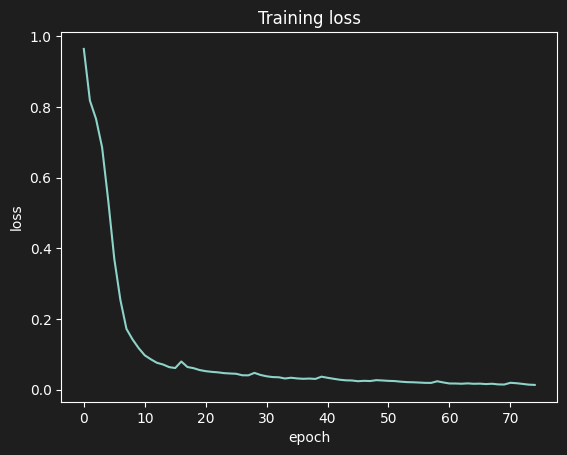

In [14]:
VF_res = SimpleResUNetFM(in_channels=3, out_channels=3).to(device)
VF_GFM, loss_hist_GFM =GFM_training_CFD(
    VF_res, 
    train_loader=train_loader, 
    n_epochs=75,
    sigma=0.1,
    lr=1e-3,
    device=device
)
plt.plot(loss_hist_GFM)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training loss');

KL divergence (velocity magnitude, pooled): 0.2064
KL divergence (pressure, pooled):           0.3672


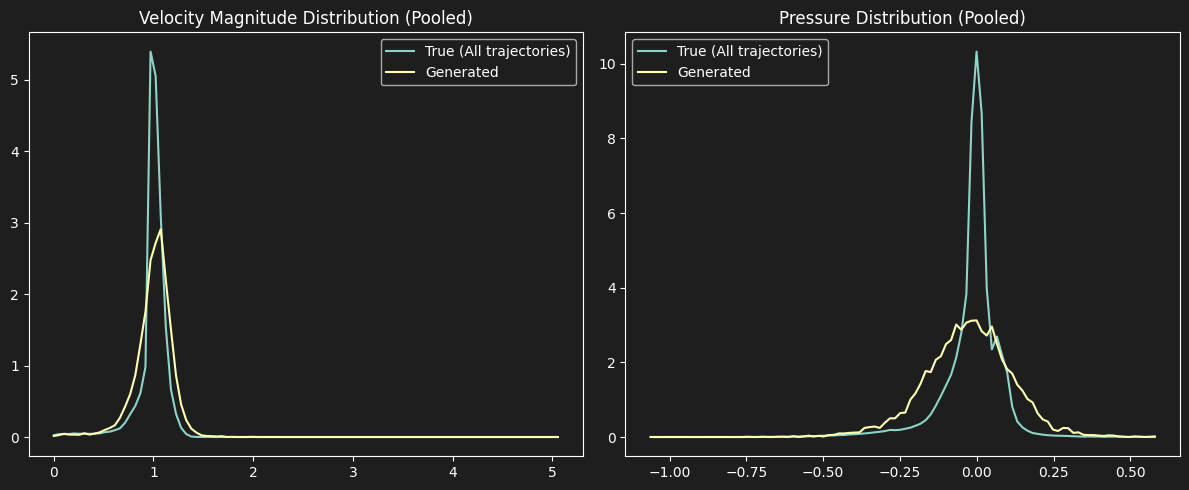

(0.20640034631766335, 0.3671983911189937)

In [ ]:
evaluate_full_trajectory(VF_res, train_dataset, n_euler_steps=100, device=device)

Time bundled model

In [ ]:


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(8 if out_ch >= 8 else 1, out_ch)
        self.norm2 = nn.GroupNorm(8 if out_ch >= 8 else 1, out_ch)
        self.act = nn.GELU()
        self.skip = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        identity = self.skip(x)
        x = self.act(self.norm1(self.conv1(x)))
        x = self.norm2(self.conv2(x))
        x = x + identity
        return self.act(x)


class SimpleResUNetFMTimeBundled(nn.Module):
    """
    Time-bundled ResNet-UNet for flow matching.
    Predicts multiple time steps (k) in a single forward pass.
    """
    def __init__(self, in_channels=3, out_channels=3, base_ch=64, k=3):
        super().__init__()
        self.k = k  

        # Encoder
        self.enc1 = ResBlock(in_channels + 1, base_ch)
        self.enc2 = ResBlock(base_ch, base_ch * 2)
        self.enc3 = ResBlock(base_ch * 2, base_ch * 4)
        self.enc4 = ResBlock(base_ch * 4, base_ch * 8)

        # Bottleneck
        self.bottleneck = ResBlock(base_ch * 8, base_ch * 8)

        # Decoder
        self.dec4 = ResBlock(base_ch * 8 + base_ch * 8, base_ch * 4)
        self.dec3 = ResBlock(base_ch * 4 + base_ch * 4, base_ch * 2)
        self.dec2 = ResBlock(base_ch * 2 + base_ch * 2, base_ch)
        self.dec1 = ResBlock(base_ch + base_ch, base_ch)

        # Output layer now produces k * out_channels
        self.out_conv = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(base_ch, out_channels * k, kernel_size=1)
        )

        self.pool = nn.AvgPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x, t):
        B, _, H, W = x.shape
        t_map = t.view(B, 1, 1, 1).expand(-1, 1, H, W)
        xt = torch.cat([x, t_map], dim=1)

        # Encoder
        e1 = self.enc1(xt)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder
        d4 = self.upsample(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.upsample(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.upsample(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.upsample(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.out_conv(d1)
        out = out.view(B, self.k, -1, H, W)  # [B, k, C, H, W]
        return out

    @torch.no_grad()
    def generation(self, x, n_euler_steps=60, device="cuda", return_sequence=False, max_push_steps=None):
        """
        Euler rollout with time bundling.
        If k>1, we apply multiple predicted steps before re-calling the model.
        """
        self.eval()
        B, C, H, W = x.shape
        k = self.k
        dt = 1.0 / n_euler_steps
        x_t = x.to(device)
        seq = []

        for step in range(0, n_euler_steps, k):
            t_val = torch.full((B,), step * dt, device=device)
            v_preds = self.forward(x_t, t_val)  # [B, k, C, H, W]

            for i in range(k):
                if step + i >= n_euler_steps:
                    break
                x_t = x_t + v_preds[:, i] * dt
                if return_sequence:
                    seq.append(x_t.detach().cpu())

        if return_sequence:
            return torch.stack(seq)
        else:
            return x_t


In [ ]:


def GCFM_training_CFD_bundled_pushforward(
    VF, train_loader, *, n_epochs=50, sigma=0.1, lr=1e-3, device="cuda",
    pushforward_prob=0.2, max_push_steps=3
):
    """
    Gaussian Conditional Flow Matching for CFD fields,
    augmented with time bundling (k outputs) and occasional push-forward.

    Assumes VF(x_t, t) -> [B, k, C, H, W]  (or [B, C, H, W] if k==1).
    """
    VF.to(device).train()
    optimizer = torch.optim.Adam(VF.parameters(), lr=lr)
    mse = nn.MSELoss()

    k = getattr(VF, "k", 1)

    loss_hist = []
    for epoch in range(n_epochs):
        running = 0.0

        for batch in train_loader:
            _, _, x1, _ = batch                    # x1: [B, 3, H, W]
            x1 = x1.to(device)
            B = x1.size(0)

            t = torch.rand(B, device=device)       # [B]
            t4 = t.view(B, 1, 1, 1)

            std = (t4 * sigma - t4 + 1).abs()
            x_t = t4 * x1 + torch.randn_like(x1) * std

            denom = 1.0 - (1.0 - sigma) * t4
            u_star = (x1 - (1.0 - sigma) * x_t) / denom

            if torch.rand(1).item() < pushforward_prob:
                n_push = torch.randint(1, max_push_steps + 1, (1,)).item()
                with torch.no_grad():
                    x_roll = x_t
                    dt = 1.0 / (k * max_push_steps)
                    for _ in range(n_push):
                        v_pred = VF(x_roll, t)               
                        if v_pred.dim() == 4:                
                            v_step = v_pred
                        else:
                            v_step = v_pred[:, 0]            
                        x_roll = x_roll + v_step * dt
                x_t = x_roll.detach()
                u_star = (x1 - (1.0 - sigma) * x_t) / denom

            preds = VF(x_t, t)                              
            if preds.dim() == 4:
                pred = preds                               
            else:
                idx = torch.randint(0, k, (1,)).item()        
                pred = preds[:, idx]                           

            loss = mse(pred, u_star)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running += loss.item()

        avg = running / len(train_loader)
        loss_hist.append(avg)
        print(f"Epoch [{epoch+1}/{n_epochs}]  GCFM loss: {avg:.6f}")

    return VF, loss_hist


In [39]:
VF_bundled_conditional = SimpleResUNetFMTimeBundled(
    in_channels=3, 
    out_channels=3, 
    base_ch=64, 
    k=7      
).to(device)

VF_bundled_conditional, loss_hist = GCFM_training_CFD_bundled_pushforward(
    VF_bundled_conditional,
    train_loader,
    n_epochs=100,
    sigma=0.1,
    lr=1e-3,
    device=device,
    pushforward_prob=0.2,
    max_push_steps=4
)


Epoch [1/100]  GCFM loss: 1.038744
Epoch [2/100]  GCFM loss: 1.124546
Epoch [3/100]  GCFM loss: 0.931292
Epoch [4/100]  GCFM loss: 0.938587
Epoch [5/100]  GCFM loss: 0.968069
Epoch [6/100]  GCFM loss: 0.885018
Epoch [7/100]  GCFM loss: 0.857041
Epoch [8/100]  GCFM loss: 0.886150
Epoch [9/100]  GCFM loss: 0.849681
Epoch [10/100]  GCFM loss: 0.830488
Epoch [11/100]  GCFM loss: 0.850934
Epoch [12/100]  GCFM loss: 0.881922
Epoch [13/100]  GCFM loss: 0.769713
Epoch [14/100]  GCFM loss: 0.766718
Epoch [15/100]  GCFM loss: 0.716859
Epoch [16/100]  GCFM loss: 0.670749
Epoch [17/100]  GCFM loss: 0.654178
Epoch [18/100]  GCFM loss: 0.614680
Epoch [19/100]  GCFM loss: 0.564817
Epoch [20/100]  GCFM loss: 0.566247
Epoch [21/100]  GCFM loss: 0.523630
Epoch [22/100]  GCFM loss: 0.456391
Epoch [23/100]  GCFM loss: 0.471152
Epoch [24/100]  GCFM loss: 0.484503
Epoch [25/100]  GCFM loss: 0.404040
Epoch [26/100]  GCFM loss: 0.372260
Epoch [27/100]  GCFM loss: 0.388393
Epoch [28/100]  GCFM loss: 0.345064
E

KL divergence (velocity magnitude, pooled): 0.1958
KL divergence (pressure, pooled):           0.3132


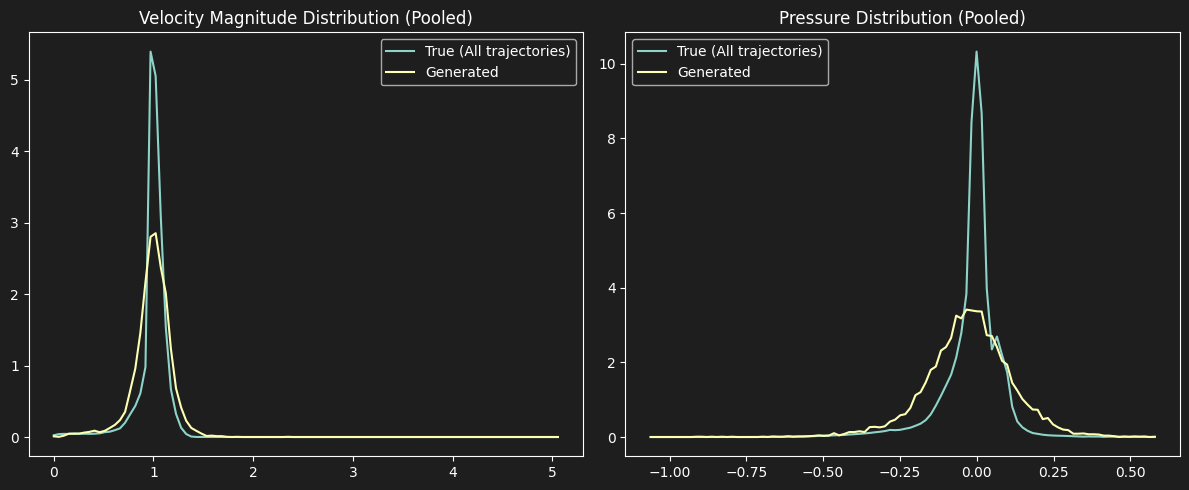

(0.1958232553611115, 0.3132457020003594)

In [41]:
evaluate_full_trajectory(VF_bundled_conditional, train_dataset, n_euler_steps=300, device=device)

Generate a single sample.

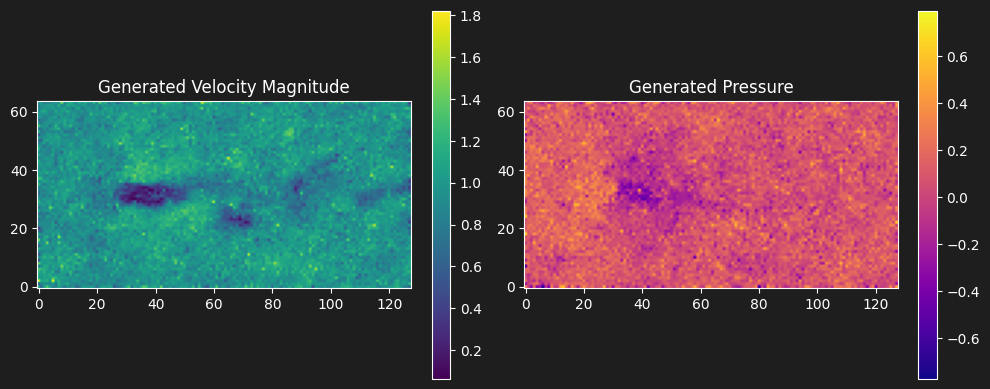

In [ ]:


@torch.no_grad()
def generate_single_sample(VF, n_steps=100, device="cuda"):
    """
    Generate one final CFD field from Gaussian noise using a trained GCFM model.
    """
    VF.eval()
    x = torch.randn(1, 3, 64, 128, device=device)  # Gaussian prior
    dt = 1.0 / n_steps

    for i in range(n_steps):
        t = torch.full((x.size(0),), i / n_steps, device=device)
        v = VF(x, t)  # [B, k, 3, H, W] or [B, 3, H, W]
        if v.dim() == 5:
            v = v[:, 0]
        x = x + v * dt  # Euler integration

    return x.squeeze(0).detach().cpu()
x_gen = generate_single_sample(VF_bundled_conditional, n_steps=300, device=device)

vx, vy, p = x_gen[0], x_gen[1], x_gen[2]
vel_mag = torch.sqrt(vx**2 + vy**2).numpy()
p = p.numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(vel_mag, cmap="viridis", origin="lower")
axes[0].set_title("Generated Velocity Magnitude")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(p, cmap="plasma", origin="lower")
axes[1].set_title("Generated Pressure")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()



In [ ]:


def _fm_std(t, sigma):

    return (t * sigma - t + 1).abs()

@torch.no_grad()
def _denoise_from_t(VF, x_t, t_start, n_substeps=200, device="cuda"):
    """
    Integrate dx/dt = v_theta(x,t) from t_start -> 1.0 using Euler.
    Works for bundled models (takes the first head).
    """
    VF.eval()
    x = x_t.to(device)
    B = x.shape[0]
    t0 = float(t_start.min().item()) if t_start.ndim > 0 else float(t_start)
    dt = (1.0 - t0) / max(1, n_substeps)

    for k in range(n_substeps):
        t = torch.full((B,), t0 + k * dt, device=device)
        v = VF(x, t)                      # [B,3,H,W] or [B,k,3,H,W]
        if v.dim() == 5:
            v = v[:, 0]                   # use first bundled head
        x = x + v * dt
    return x

@torch.no_grad()
def fm_markov_chain(
    VF, *,
    steps=10,                   
    H=64, W=128,                 
    sigma=0.1,                   
    s_min=0.2, s_max=0.6,        
    n_substeps=200,              
    device="cuda"
):
    """
    Step 0: sample x^(0) by integrating from prior (noise) at t=0 -> t=1.
    Step n>0: re-noise previous sample to t=s, then denoise back to 1.
              x_t = s * x^(n-1) + std(s)*z,  then integrate to 1.
    Returns: [steps, 3, H, W] tensor of samples.
    """
    VF.eval()
    chain = []

    x = torch.randn(1, 3, H, W, device=device)
    x = _denoise_from_t(VF, x_t=x, t_start=torch.tensor(0.0, device=device), n_substeps=n_substeps, device=device)
    chain.append(x.squeeze(0).detach().cpu())

    for _ in range(1, steps):
        s = torch.empty(1, device=device).uniform_(s_min, s_max) 
        s4 = s.view(1,1,1,1)
        std = _fm_std(s4, torch.tensor(sigma, device=device))
        z = torch.randn_like(x)
        x_t = s4 * x + std * z
        x = _denoise_from_t(VF, x_t=x_t, t_start=s, n_substeps=n_substeps, device=device)
        chain.append(x.squeeze(0).detach().cpu())

    return torch.stack(chain)   


Rollout function that starts from noise, generates a sample and then uses the generated sample xt as the input to generate the sample xt+1.

In [22]:
def show_chain_gif(chain, fps=2, quantity="velocity"):
    """
    chain: [T, 3, H, W] tensor (output of fm_markov_chain)
    quantity: 'velocity' or 'pressure'
    """
    seq = chain.numpy()
    frames = []
    for t in range(seq.shape[0]):
        u, v, p = seq[t]
        if quantity == "velocity":
            data = np.sqrt(u**2 + v**2)
            cmap, title = "coolwarm", f"Sample {t+1}: |v|"
        else:
            data = p
            cmap, title = "plasma", f"Sample {t+1}: p"

        fig, ax = plt.subplots(figsize=(6, 3))
        ax.imshow(data, cmap=cmap, origin="lower")
        ax.set_title(title)
        ax.axis("off")
        plt.tight_layout()

        buf = io.BytesIO()
        plt.savefig(buf, format="png", bbox_inches="tight", pad_inches=0)
        plt.close(fig)
        buf.seek(0)
        frames.append(PILImage.open(buf))

    gif_buf = io.BytesIO()
    frames[0].save(gif_buf, format="GIF", save_all=True,
                   append_images=frames[1:], duration=int(1000/fps), loop=0)
    gif_buf.seek(0)
    display(Image(data=gif_buf.read()))


In [ ]:


def animate_chain_rollout(chain, output_path="output/chain_rollout.gif", fps=2):
    """
    Animate a Markov chain of generated samples (velocity + pressure)
    in the same visual style as your previous rollout animations.

    Args:
        chain: [T, 3, H, W] tensor (Markov chain of samples)
        output_path: file path for output GIF
        fps: frames per second
    """
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    chain = chain.detach().cpu()
    T, _, H, W = chain.shape

    vel = torch.sqrt(chain[:,0]**2 + chain[:,1]**2)
    p = chain[:,2]

    vmax_vel = vel.max().item()
    vmax_p = p.max().item()

    fig, axes = plt.subplots(2, 3, figsize=(15, 5))
    titles = ["Current", "Next", "Δ (abs diff)"]
    imgs = []

    for i in range(2):  
        row_imgs = []
        for j in range(3):
            ax = axes[i, j]
            img = ax.imshow(np.zeros((H, W)), cmap='viridis',
                            vmin=0, vmax=vmax_vel if i == 0 else vmax_p)
            ax.set_title(titles[j])
            ax.set_xticks([]); ax.set_yticks([])
            for s in ax.spines.values(): s.set_visible(False)
            row_imgs.append(img)
        imgs.append(row_imgs)

    axes[0,0].set_ylabel(r'$\sqrt{v_x^2 + v_y^2}$', fontsize=12)
    axes[1,0].set_ylabel(r'$p$', fontsize=12)
    imgs[0][2].set_cmap('magma')
    imgs[1][2].set_cmap('magma')

    def init():
        for i in range(2):
            for j in range(3):
                imgs[i][j].set_data(np.zeros((H, W)))
        return [img for row in imgs for img in row]

    def update(frame):
        if frame >= T-1:
            frame = T-2

        vel_curr, vel_next = vel[frame], vel[frame+1]
        p_curr, p_next = p[frame], p[frame+1]

        imgs[0][0].set_data(vel_curr)
        imgs[0][1].set_data(vel_next)
        imgs[0][2].set_data(np.abs(vel_next - vel_curr))

        imgs[1][0].set_data(p_curr)
        imgs[1][1].set_data(p_next)
        imgs[1][2].set_data(np.abs(p_next - p_curr))

        fig.suptitle(f"Chain Step {frame+1}/{T-1}", fontsize=14)
        return [img for row in imgs for img in row]

    ani = animation.FuncAnimation(
        fig, update, frames=T-1, init_func=init,
        blit=False, interval=1000/fps
    )

    ani.save(output_path, writer="ffmpeg", dpi=150)
    plt.close(fig)
    print(f" Saved chain rollout visualization to {output_path}")


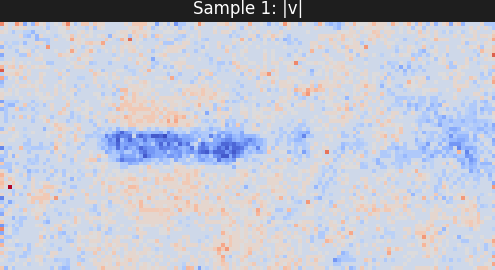

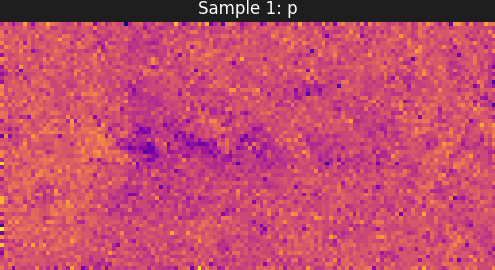

In [44]:
chain = fm_markov_chain(
    VF_bundled_conditional, steps=12, H=64, W=128,
    sigma=0.1, s_min=0.25, s_max=0.55,
    n_substeps=250, device=device
)

show_chain_gif(chain, fps=2, quantity="velocity")

show_chain_gif(chain, fps=2, quantity="pressure")


In [45]:
animate_chain_rollout(chain, output_path="output/gcfm_chain_rollout.gif", fps=2)


MovieWriter ffmpeg unavailable; using Pillow instead.


 Saved chain rollout visualization to output/gcfm_chain_rollout.gif
